# Granite for Bike Rental Predictions

This notebook explores using granite to obtain regional explanations on the BikeSharing dataset.
## Setup

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error
from joblib import dump, load

# Local imports
from granite.data import get_data_bike

### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [3]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_bike()
# Make months and weekdays smaller for the plots (optional)
features.feature_objs[1].cats = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
features.feature_objs[4].cats = ["M", "T", "W", "T", "F", "S", "S"]
features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | yr                 | ordinal            | 2          | [0]              |
| 1 | mnth               | ordinal            | 12         | [1]              |
| 2 | hr                 | num_int            | 24         | [2]              |
| 3 | holiday            | bool               | 2          | [3]              |
| 4 | weekday            | ordinal            | 7          | [4]              |
| 5 | workingday         | bool               | 2          | [5]              |
| 6 | weathersit         | num_int            | 4          | [6]              |
| 7 | temp               | num                | inf        | [7]              |
| 8 | hum                | num                | inf        | [8]              |
| 9 | windspeed          | num                | inf        | [9]              |
----------------------------------------

This dataset involves 10 features of various types. The following Table can help understand their meaning and domain.

<p align="center">
    <img src="./Images/Features_bike.png" width="600">
</p>

### Fitting the model
Having fetched the data, we fit a `HistGradientBoostingRegressor`.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = HistGradientBoostingRegressor(random_state=0)

**Do not run the following cells if you have already trained the model. Skip to later cells.**

In [ ]:
grid = {"learning_rate": np.logspace(-2, 0, 10),
        "max_depth" : [3, 4, 5, 6, 7],
        "max_iter" : [50, 100, 150, 200],
        'min_samples_leaf' : [1, 20, 40, 60, 80, 100]}

search = RandomizedSearchCV(
    model,
    cv=KFold(),
    scoring='neg_root_mean_squared_error',
    param_distributions=grid,
    verbose=2,
    n_iter=20,
    random_state=42
)
search.fit(X_train, y_train)

In [5]:
# Recover the optimal CV model
model = search.best_estimator_
res = search.cv_results_
cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
best_idx = np.argmin(cv_perf)

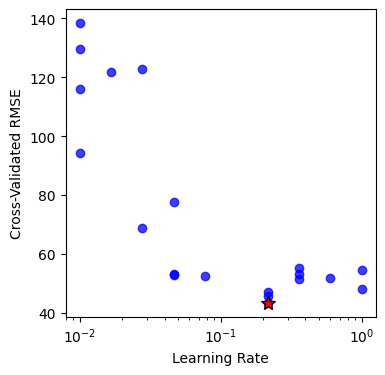

In [6]:
plt.figure(figsize=(4, 4))
plt.scatter(res['param_learning_rate'], cv_perf, c='b', alpha=0.75)
plt.plot(res['param_learning_rate'][best_idx], cv_perf[best_idx], 'r*', markersize=10, markeredgecolor='k')
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validated RMSE")
plt.xscale('log')

In [7]:
# Pickle the model
dump(model, os.path.join("models", "bike_gbt.joblib"))

['models/bike_gbt.joblib']

**Start from here if you have already trained and dumped the model.**

In [5]:
# Load the model
model = load(os.path.join("models", "bike_gbt.joblib"))
test_preds = model.predict(X_test)
print(f" RMSE of the model : {root_mean_squared_error(test_preds, y_test):.2f}")
print(f" Std dev of the target : {y_test.std():.2f}")

 RMSE of the model : 43.08
 Std dev of the target : 181.45


## Computing Marginal Pure-Full Effects

We can understand how an individual features impact the model response by computing their pure and full marginal effects. Here we study the 7th feature `temp`.

In [ ]:
from granite.decompositions import get_components_tree
# Compute the H^k matrices using a subset of 1000 training points
background = X_train[:2000]
decomposition = get_components_tree(model, background, background, features.select([7]), anchored=True)

In [ ]:
# The keys are tuples encoding subsets of features
print(decomposition.keys())
# The () key is the intercept
print(decomposition[()].shape)
# The key (0,) is the main effect of 7, the only feature given to the decomposition
print(decomposition[(0,)].shape)

dict_keys([(), (0,)])
(2000,)
(2000, 2000)


For instance we can investigate how `temp` affects the model output.

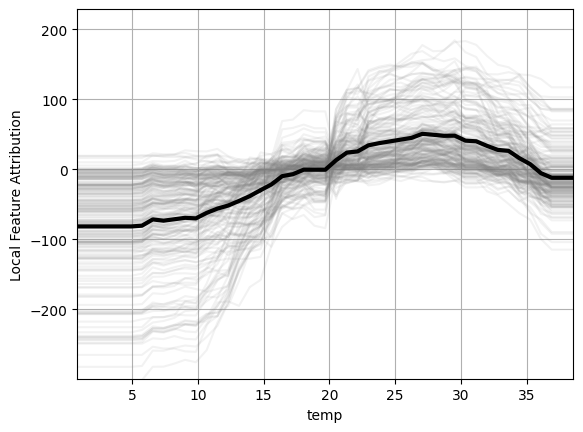

In [13]:
from granite.plots import partial_dependence_plot

# We plot the h_i terms along side the Shapley Values
partial_dependence_plot(decomposition, background, features.select([7]), centered=True)

In this plot, the dark line is the PDP while the thin lines are the ICEs. Difference between the two are indicators of feature interactions involving `temp`. This means that the effect of increasing/decreasing temperature depends on the value of
other features. Our local explanations should account for these interactions.

In [14]:
from granite.fd_trees import FDTree


class Minimize_Superset(FDTree):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def fit(self, X, decomposition, u):
        """
        Fit the FDTree

        Parameters
        ----------
        X : (N, n_features) np.ndarray
            The data on which to fit the tree. The ith column of `X` must be the ith feature
            in the Features object passed to the constructor.
        decomposition : dict{Tuple: np.ndarray}
            The functional decomposition used to compute the objective.
            It needs to be anchored with foreground=background i.e.
            `decomposition[(0,)].shape = (N, N)`.
        u : Tuple(int)
            The subset whose pure-full disagreement is minimized
        """

        self.X = X
        self.N, self.D = X.shape
        self.u = u
        assert np.shape(decomposition[u]) == (self.N, self.N), "An Anchored decomposition with foreground=background is needed"
        self.H = decomposition[u]
        self.loa_factor = 1 / self.H.mean(1).var()
        self.n_regions = 0
        # Loss function is the difference between full and partial effects
        loa = np.mean((self.H.mean(0) - (-1)**len(u)*self.H.mean(1))**2)
        # Start recursive tree growth
        self.root, self.final_objective, self.n_regions = self._tree_builder(np.arange(self.N), depth=0, loa=loa)
        self.final_loa = self.final_objective - self.alpha * self.n_regions
        return self


    def _get_objective_for_splits(self, instances_idx, feature):
        """
        Given the indices of the datapoints in the current leaf, compute
        the loss function for a variety of split candidates.
        """
        x_i = self.X[instances_idx, feature]

        splits = self._get_split_candidates(x_i, feature)

        # No split possible
        if len(splits) == 0:
            return [], [], []

        # Otherwise we optimize the objective
        loa_left = np.zeros(len(splits))
        loa_right = np.zeros(len(splits))
        to_keep = np.zeros((len(splits))).astype(bool)

        # Iterate over all splits
        for i, split in enumerate(splits):
            left = instances_idx[x_i <= split][:, np.newaxis]
            right = instances_idx[x_i > split][:, np.newaxis]
            H_left = self.H[left, left.T]
            H_right = self.H[right, right.T]
            to_keep[i] = min(len(left), len(right)) >= self.min_samples_leaf
            loa_left[i]  = np.sum((H_left.mean(0) - (-1)**len(self.u)*H_left.mean(1))**2)
            loa_right[i]  = np.sum((H_right.mean(0) - (-1)**len(self.u)*H_right.mean(1))**2)

        return splits[to_keep], loa_left[to_keep], loa_right[to_keep]

In [15]:
# from granite.fd_trees import GADGET_PDP

# Split along remaining features to minimize superset error
features_to_split_upon = [i for i in range(len(features)) if not i == 7]
tree = Minimize_Superset(max_depth=3, features=features.select(features_to_split_upon), alpha=0.07)
tree.fit(background[:, features_to_split_upon], decomposition, u=(0,))

# partial_decomp = {}
# partial_decomp[()] = decomposition[()]
# partial_decomp[(0,)] = decomposition[(7,)]
# tree = GADGET_PDP(features.select(features_to_split_upon), max_depth=3, alpha=0.01)
# tree.fit(background[:, features_to_split_upon], partial_decomp)

tree.print(verbose=True)

LoA 1.0597
Samples 2000
If hr ≤ 10.0000:
|   LoA 0.1488
|   Samples 883
|   Region 0
else:
|   LoA 0.5527
|   Samples 1117
|   If mnth ≤ 1.0000:
|   |   LoA 0.0278
|   |   Samples 167
|   |   Region 1
|   else:
|   |   LoA 0.3420
|   |   Samples 950
|   |   If mnth ≤ 9.0000:
|   |   |   LoA 0.1955
|   |   |   Samples 767
|   |   |   Region 2
|   |   else:
|   |   |   LoA 0.0444
|   |   |   Samples 183
|   |   |   Region 3
Final LoA 0.4165


In [23]:
# Using regional backgrounds
larger_background = X[:4000]
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()
print(rules)

(array([0, 1, 2, 3], dtype=int32), array([1835,  358, 1429,  378]))
{0: 'hr<=10.00', 1: '(hr>10.00 & mnth ∈ [J,F])', 2: '(hr>10.00 & mnth ∈ [M,A,M,J,J,A,S,O,N,D] & mnth ∈ [J,F,M,A,M,J,J,A,S,O])', 3: '(hr>10.00 & mnth ∈ [M,A,M,J,J,A,S,O,N,D] & mnth ∈ [N,D])'}


In [ ]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
regional_shap = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(model,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features.select([7]),
                                                    anchored=True)

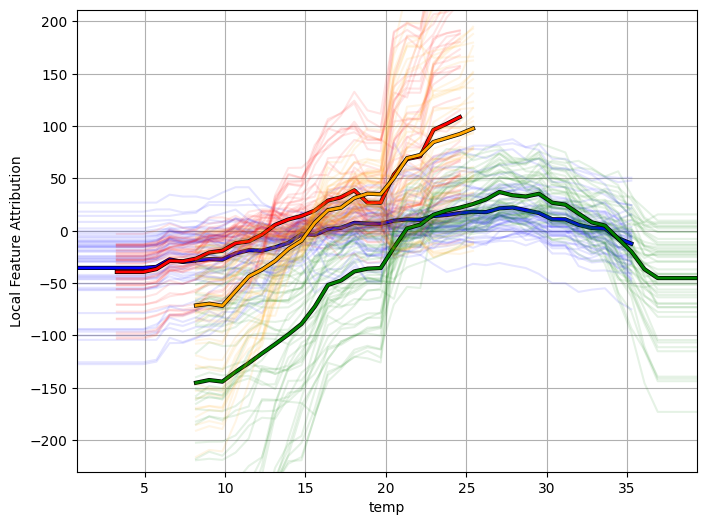

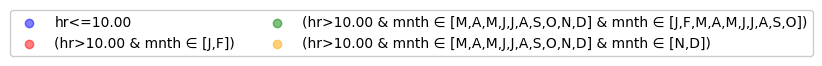

In [27]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features.select([7]), centered=True, figsize=(8, 6))
plot_legend(rules, ncol=2)

## Computing Marginal and Conditional Effects

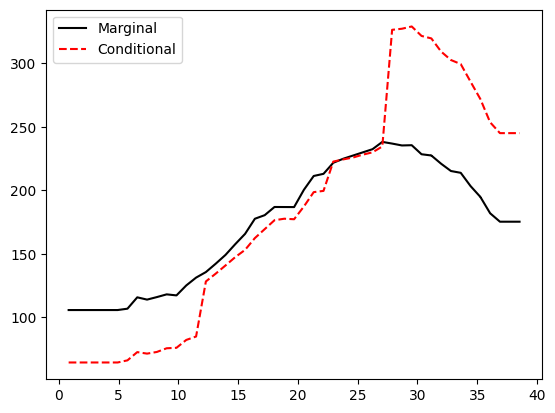

In [45]:
n_bins=5
quantiles = np.percentile(background[:, 7], q=[i*100 / n_bins for i in range(n_bins+1)], axis=0)
binned_feature = np.clip(np.digitize(background[:, 7], bins=quantiles) - 1, a_min=0, a_max=n_bins-1)
R = decomposition[(0,)] + decomposition[()]

def get_marginal_conditional_effects(binned_feature, R):
    marginal_effect = R.mean(1)
    conditional_effect = np.zeros((binned_feature.shape[0],))
    for b in np.unique(binned_feature):
        inside_bin = np.where(binned_feature == b)[0][:, np.newaxis]
        conditional_effect[inside_bin.ravel()] = R[inside_bin, inside_bin.T].mean(1)
    return marginal_effect, conditional_effect

marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_feature, R)
argsort_x_i = np.argsort(background[:, 7])
plt.plot(background[argsort_x_i, 7], marginal_effect[argsort_x_i], 'k-', label="Marginal")
plt.plot(background[argsort_x_i, 7], conditional_effect[argsort_x_i], 'r--', label="Conditional")
# plt.ylim(-6, 6)
plt.legend()

In [46]:
class PDP_vs_MPlot(FDTree):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def fit(self, X, decomposition, i, binned_feature):
        """
        Fit the FDTree

        Parameters
        ----------
        X : (N, n_features) np.ndarray
            The data on which to fit the tree. The ith column of `X` must be the ith feature
            in the Features object passed to the constructor.
        decomposition : dict{Tuple: np.ndarray}
            The functional decomposition used to compute the objective.
            It needs to be anchored with foreground=background i.e.
            `decomposition[(0,)].shape = (N, N)`.
        i : int
            The index of the feature whose marginal and conditional effects are computed.
        binned_feature : np.ndarray[int]
            Binned values for feature i, used to compute conditional expectations
        """

        self.X = X
        self.N, self.D = X.shape
        assert np.shape(decomposition[(i,)]) == (self.N, self.N), "An Anchored decomposition with foreground=background is needed"
        self.R = decomposition[(i,)] + decomposition[()]
        self.loa_factor = 1 / self.R.var()
        self.binned_data = binned_feature
        self.n_regions = 0
        marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_feature, self.R)
        # The loss is the difference between the marginal and conditional effects
        loa = np.mean((marginal_effect - conditional_effect)**2)
        # Start recursive tree growth
        self.root, self.final_objective, self.n_regions = self._tree_builder(np.arange(self.N), depth=0, loa=loa)
        self.final_loa = self.final_objective - self.alpha * self.n_regions
        return self


    def _get_objective_for_splits(self, instances_idx, feature):
        x_i = self.X[instances_idx, feature]

        splits = self._get_split_candidates(x_i, feature)

        # No split possible
        if len(splits) == 0:
            return [], [], []

        # Otherwise we optimize the objective
        loa_left = np.zeros(len(splits))
        loa_right = np.zeros(len(splits))
        to_keep = np.zeros((len(splits))).astype(bool)

        # Iterate over all splits
        for i, split in enumerate(splits):
            left = instances_idx[x_i <= split][:, np.newaxis]
            right = instances_idx[x_i > split][:, np.newaxis]
            R_left = self.R[left, left.T]
            R_right = self.R[right, right.T]
            to_keep[i] = min(len(left), len(right)) >= self.min_samples_leaf
            marginal_left, conditional_left = get_marginal_conditional_effects(self.binned_data[left.ravel()], R_left)
            marginal_right, conditional_right = get_marginal_conditional_effects(self.binned_data[right.ravel()], R_right)
            loa_left[i]  = np.sum((marginal_left - conditional_left)**2)
            loa_right[i]  = np.sum((marginal_right - conditional_right)**2)

        return splits[to_keep], loa_left[to_keep], loa_right[to_keep]

In [47]:
# We only split along the features that exclude X_4
tree = PDP_vs_MPlot(features.select(features_to_split_upon), max_depth=3, save_losses=True, branching_per_node=3, alpha=0.005)
tree.fit(background[:, features_to_split_upon], decomposition, 0, binned_feature=binned_feature)
tree.print(verbose=True)

LoA 0.0679
Samples 2000
If hr ≤ 6.0000:
|   LoA 0.0001
|   Samples 557
|   Region 0
else:
|   LoA 0.0278
|   Samples 1443
|   If mnth ≤ 1.0000:
|   |   LoA 0.0027
|   |   Samples 227
|   |   Region 1
|   else:
|   |   LoA 0.0200
|   |   Samples 1216
|   |   If hum ≤ 0.7400:
|   |   |   LoA 0.0099
|   |   |   Samples 931
|   |   |   Region 2
|   |   else:
|   |   |   LoA 0.0007
|   |   |   Samples 285
|   |   |   Region 3
Final LoA 0.0133


In [ ]:

larger_background = X[:5000]
binned_feature = np.clip(np.digitize(larger_background[:, 7], bins=quantiles) - 1, a_min=0, a_max=n_bins-1)
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()

regional_decompositions = [[]] * tree.n_regions
regional_backgrounds = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions == r]
    regional_decompositions[r] = get_components_tree(model, regional_backgrounds[r], regional_backgrounds[r], features.select([7]), anchored=True)

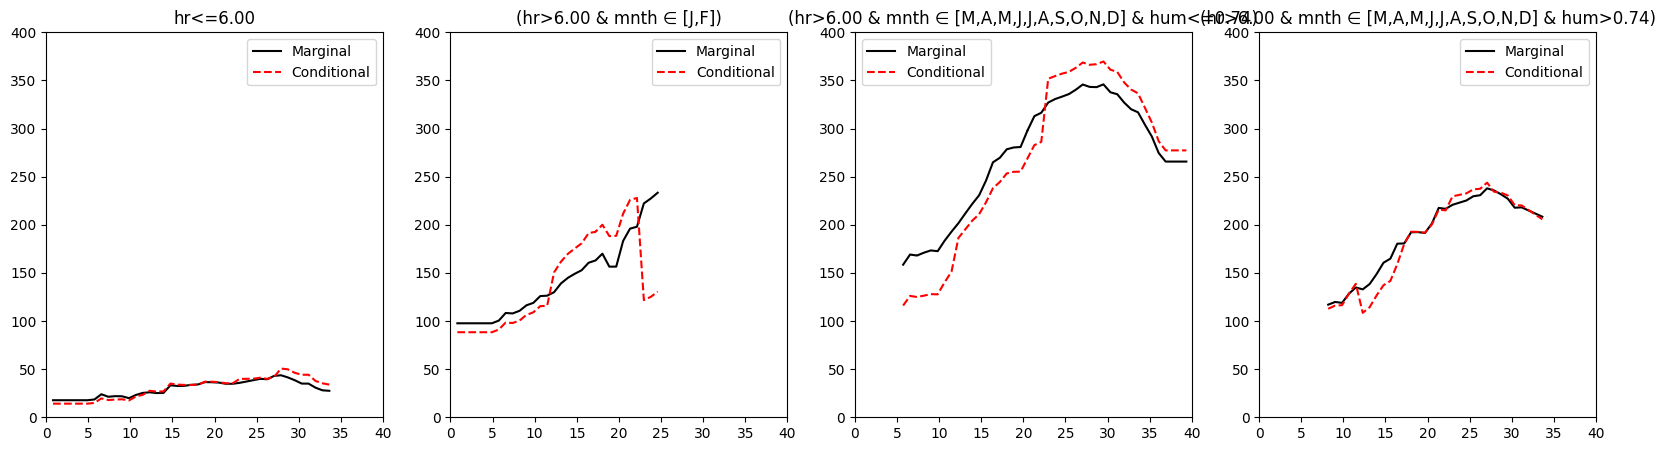

In [49]:
fig, axes = plt.subplots(1, tree.n_regions, figsize=(20, 5))
for r in range(tree.n_regions):
    R = regional_decompositions[r][(0,)] + regional_decompositions[r][()]
    X_region = regional_backgrounds[r]
    marginal_effect, conditional_effect = get_marginal_conditional_effects(binned_feature[regions==r], R)
    argsort_x_i = np.argsort(X_region[:, 7])
    axes[r].plot(X_region[argsort_x_i, 7], marginal_effect[argsort_x_i], 'k-', label="Marginal")
    axes[r].plot(X_region[argsort_x_i, 7], conditional_effect[argsort_x_i], 'r--', label="Conditional")
    axes[r].set_xlim(0, 40)
    axes[r].set_ylim(0, 400)
    axes[r].set_title(rules[r])
    axes[r].legend()